<a href="https://colab.research.google.com/github/rakesh-mandal/ML/blob/main/Placement_Prediction/placement_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('/content/placement.csv')

In [ ]:
df

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [ ]:
df.shape

(100, 4)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [ ]:

# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [ ]:
# df = df.drop('Unnamed: 0', axis=1)
# df.drop('Unnamed: 0', axis=1, inplace=True)

df=df.iloc[:, 1:]


In [ ]:
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [ ]:
import matplotlib.pyplot as plt

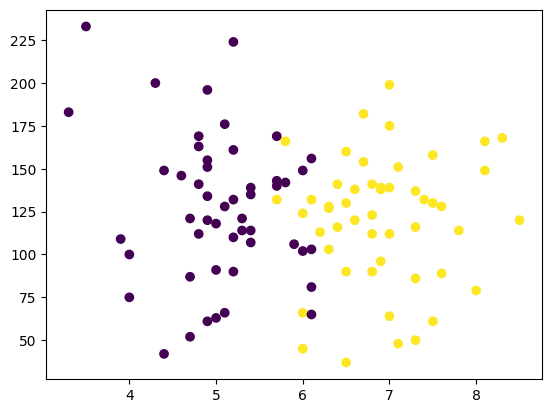

In [ ]:

plt.scatter(df['cgpa'],df['iq'],c=df['placement'])



In [ ]:
import seaborn as sns

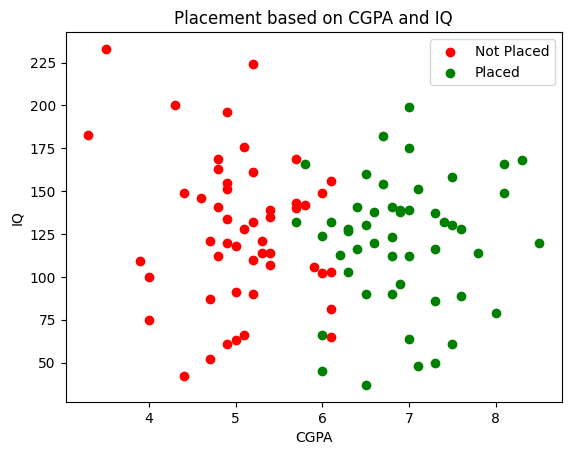

In [ ]:
plt.scatter(df[df['placement']==0]['cgpa'],
            df[df['placement']==0]['iq'],
            color='red',
            label='Not Placed')

plt.scatter(df[df['placement']==1]['cgpa'],
            df[df['placement']==1]['iq'],
            color='green',
            label='Placed')

plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.title('Placement based on CGPA and IQ')
plt.legend()

plt.show()

In [ ]:
X= df.iloc[:, 0:2]
y= df.iloc[:, -1]

In [ ]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [ ]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [ ]:

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)


In [ ]:
X_train

,cgpa,iq
27,6.0,124.0
32,7.0,139.0
65,8.1,166.0
5,7.1,48.0
84,5.7,169.0
...,...,...
4,5.8,142.0
52,7.0,175.0
93,6.8,112.0
91,7.5,158.0


In [ ]:
y_train

,placement
27,1
32,1
65,1
5,1
84,0
...,...
4,0
52,1
93,1
91,1


In [ ]:
X_test

,cgpa,iq
57,6.5,130.0
56,6.1,65.0
33,6.0,149.0
16,5.2,224.0
96,4.4,42.0
34,4.8,163.0
88,4.4,149.0
14,6.1,103.0
6,5.7,143.0
31,3.9,109.0


In [ ]:
y_test

,placement
57,1
56,0
33,0
16,0
96,0
34,0
88,0
14,0
6,0
31,0


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train = scaler.fit_transform(X_train)

In [ ]:
X_train

array([[-0.05844057,  0.02275978],
       [ 0.81816802,  0.41169268],
       [ 1.78243747,  1.11177191],
       [ 0.90582888, -1.9478336 ],
       [-0.32142315,  1.18955849],
       [ 0.73050716,  0.38576382],
       [-1.81165776, -0.59953287],
       [-1.02271002, -0.08095566],
       [-1.11037088,  0.4635504 ],
       [-1.19803174, -0.0550268 ],
       [ 0.204542  ,  0.10054636],
       [ 0.6428463 , -0.00316908],
       [-0.23376229,  1.11177191],
       [-0.32142315,  0.23019066],
       [ 1.0811506 , -0.96253691],
       [ 1.25647231, -1.61075841],
       [-0.84738831, -1.48111411],
       [-0.75972745, -0.85882147],
       [ 0.55518544,  1.52663367],
       [-2.24996205,  2.84900554],
       [ 0.37986372, -2.23305106],
       [ 0.11688115, -0.26245768],
       [-1.19803174, -0.93660805],
       [-2.42528377,  1.55256253],
       [-0.84738831,  1.37106051],
       [ 2.13308091, -0.08095566],
       [ 0.73050716, -0.70324831],
       [-0.84738831,  0.12647522],
       [ 1.69477661,

In [ ]:
X_test=scaler.fit_transform(X_test)

In [ ]:
X_test

array([[ 1.40155275,  0.0470446 ],
       [ 0.93044258, -1.28247678],
       [ 0.81266504,  0.43567393],
       [-0.1295553 ,  1.96973707],
       [-1.07177563, -1.75292281],
       [-0.60066547,  0.72203238],
       [-1.07177563,  0.43567393],
       [ 0.93044258, -0.50521813],
       [ 0.45933241,  0.31294888],
       [-1.66066335, -0.38249308]])

In [ ]:

from sklearn.linear_model import LogisticRegression

In [ ]:
clf=LogisticRegression()

In [ ]:
# model training
clf.fit(X_train,y_train)

LogisticRegression()

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
y_pred

array([1, 1, 1, 0, 0, 0, 0, 1, 1, 0])

In [ ]:
y_test

,placement
57,1
56,0
33,0
16,0
96,0
34,0
88,0
14,0
6,0
31,0


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test,y_pred)

0.6

In [ ]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

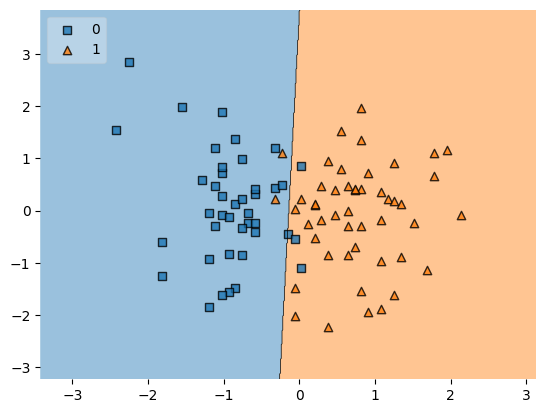

In [ ]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)